[rho0] 601 steady states in 0.56 s
[spectrum] total 25.95 s (801 x 601 grid)
max G2 (raw): 92.9013196199569
max G2 (etalon): 5.730810681893414


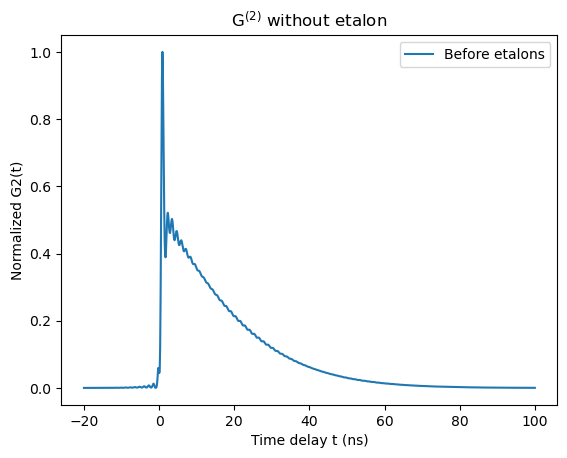

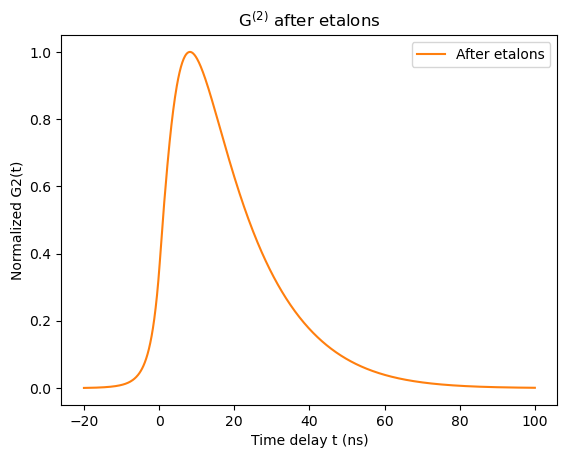

In [17]:
import os
import time
import numpy as np
import matplotlib
# matplotlib.use("Agg")            # safe on headless SLURM nodes
import matplotlib.pyplot as plt

# -----------------------------
# Constants (unchanged)
# -----------------------------
Gamma  = 2*np.pi*6e6
Gamma2 = Gamma
Gamma3 = Gamma
Gamma4 = Gamma/3
gamma  = 0.4*Gamma

Omega_c = 17*Gamma
Omega_p = 78*Gamma

kp_over_kc = 795/1476
ks_over_kc = 795/1529


def unpack_zeroth(x):
    rho11, rho22, rho33, rho44 = x[0:4]
    rho21 = x[4] + 1j*x[5]
    rho42 = x[6] + 1j*x[7]
    rho41 = x[8] + 1j*x[9]
    return rho11, rho22, rho33, rho44, rho21, rho42, rho41


def zeroth_obe_residual(x, Delta_c, Delta_p, omega_D,
                        Omega_c, Omega_p, Gamma2, Gamma3, Gamma4, gamma):
    """Identical physics to the original residual (Eqs. A1-A7)."""
    rho11, rho22, rho33, rho44, rho21, rho42, rho41 = unpack_zeroth(x)

    e1 = rho11 + rho22 + rho33 + rho44 - 1
    e2 = (-Gamma2*rho22 + (Gamma4/2)*rho44
          + 0.5j*(Omega_c*np.conj(rho21) - np.conj(Omega_c)*rho21
                  + np.conj(Omega_p)*rho42 - Omega_p*np.conj(rho42)))
    e3 = -Gamma3*rho33 + (Gamma4/2)*rho44
    e4 = (-Gamma4*rho44
          + 0.5j*(Omega_p*np.conj(rho42) - np.conj(Omega_p)*rho42))
    e5 = (1j*(Delta_c - omega_D)*rho21 - (Gamma2/2 + gamma)*rho21
          + 0.5j*(Omega_c*rho11 - Omega_c*rho22 + np.conj(Omega_p)*rho41))
    e6 = (1j*(Delta_p - kp_over_kc*omega_D)*rho42
          - (Gamma2/2 + Gamma4/2 + gamma)*rho42
          + 0.5j*(Omega_p*rho22 - Omega_p*rho44 - np.conj(Omega_c)*rho41))
    e7 = (1j*(Delta_c - omega_D + Delta_p - kp_over_kc*omega_D)*rho41
          - (Gamma4/2 + gamma)*rho41
          + 0.5j*(Omega_p*rho21 - Omega_c*rho42))

    return np.array([
        np.real(e1), np.real(e2), np.real(e3), np.real(e4),
        np.real(e5), np.imag(e5),
        np.real(e6), np.imag(e6),
        np.real(e7), np.imag(e7),
    ])


# =====================================================================
# OPTIMIZATION 1: zeroth order as a DIRECT linear solve (no root finder)
# ---------------------------------------------------------------------
# The residual is affine in x: residual(x) = A @ x + f0.
# We recover A by probing with unit vectors, then solve A x = -f0.
# Exact, always "converges", and ~10-50x faster per point than hybr.
# =====================================================================
def solve_zeroth_linear(Delta_c, Delta_p, omega_D):
    args = (Delta_c, Delta_p, omega_D,
            Omega_c, Omega_p, Gamma2, Gamma3, Gamma4, gamma)
    f0 = zeroth_obe_residual(np.zeros(10), *args)
    A = np.empty((10, 10))
    e = np.zeros(10)
    for k in range(10):
        e[:] = 0.0
        e[k] = 1.0
        A[:, k] = zeroth_obe_residual(e, *args) - f0
    return unpack_zeroth(np.linalg.solve(A, -f0))


# =====================================================================
# OPTIMIZATION 2: rho0 depends only on omega_D (not Delta_s)
# -> compute it ONCE per Doppler point, reuse for every Delta_s.
# =====================================================================
def precompute_rho0_arrays(Delta_c, Delta_p, wD_grid):
    n = len(wD_grid)
    r11 = np.empty(n); r22 = np.empty(n); r33 = np.empty(n); r44 = np.empty(n)
    r21 = np.empty(n, complex); r42 = np.empty(n, complex); r41 = np.empty(n, complex)
    for j, wD in enumerate(wD_grid):
        a, b, c, d, e, f, g = solve_zeroth_linear(Delta_c, Delta_p, wD)
        r11[j], r22[j], r33[j], r44[j] = a, b, c, d
        r21[j], r42[j], r41[j] = e, f, g
    return r11, r22, r33, r44, r21, r42, r41


# =====================================================================
# OPTIMIZATION 3: batched first-order solve
# ---------------------------------------------------------------------
# The 6x6 matrix M depends on (Delta_s, omega_D); the RHS b depends
# only on rho0 (i.e. omega_D) and on which weak drive is probed.
# The three probes (Omega_s*, Omega_s, Omega_i) share the same M,
# so we stack them as 3 columns and solve M X = B once.
# All (Delta_s x omega_D) systems are solved in one batched call.
# =====================================================================
def build_first_order_rhs(rho0_arrays):
    """B has shape (N_wD, 6, 3); columns = probes (Os*, Os, Oi)."""
    r11, r22, r33, r44, r21, r42, r41 = rho0_arrays
    n = len(r11)
    B = np.zeros((n, 6, 3), dtype=complex)

    # Probe 0: Omega_s_conj = 1 (all other drives 0)
    B[:, 1, 0] = -0.5j * r42
    B[:, 2, 0] = -0.5j * r41
    B[:, 3, 0] = +0.5j * (r33 - r44)

    # Probe 1: Omega_s = 1
    B[:, 0, 1] = -0.5j * (r33 - r44)
    B[:, 4, 1] = +0.5j * np.conj(r42)
    B[:, 5, 1] = +0.5j * np.conj(r41)

    # Probe 2: Omega_i = 1
    B[:, 1, 2] = -0.5j * np.conj(r21)
    B[:, 2, 2] = -0.5j * (r11 - r33)
    B[:, 3, 2] = -0.5j * np.conj(r41)
    return B


def build_first_order_matrices(Ds_col, wD_row, Delta_c, Delta_p):
    """M has shape (n_Ds, n_wD, 6, 6). Ds_col: (n,1), wD_row: (1,m)."""
    g43 = Gamma3/2 + Gamma4/2 + gamma
    g32 = Gamma3/2 + Gamma2/2 + gamma
    g31 = Gamma3/2 + gamma

    A43 = 1j*(Ds_col - ks_over_kc*wD_row) - g43
    A32 = 1j*(Delta_p - kp_over_kc*wD_row - Ds_col + ks_over_kc*wD_row) - g32
    A31 = 1j*(Delta_c - wD_row + Delta_p - kp_over_kc*wD_row
              - Ds_col + ks_over_kc*wD_row) - g31

    n, m = A43.shape
    M = np.zeros((n, m, 6, 6), dtype=complex)
    M[..., 0, 0] = A43
    M[..., 0, 4] = 0.5j * Omega_p
    M[..., 1, 1] = A32
    M[..., 1, 2] = -0.5j * np.conj(Omega_c)
    M[..., 1, 3] = -0.5j * Omega_p
    M[..., 2, 2] = A31
    M[..., 2, 1] = -0.5j * Omega_c
    M[..., 3, 3] = np.conj(A43)
    M[..., 3, 1] = -0.5j * np.conj(Omega_p)
    M[..., 4, 4] = np.conj(A32)
    M[..., 4, 5] = +0.5j * Omega_c
    M[..., 4, 0] = +0.5j * np.conj(Omega_p)
    M[..., 5, 5] = np.conj(A31)
    M[..., 5, 4] = +0.5j * np.conj(Omega_c)
    return M


def doppler_weight(wD, Gamma_D):
    return np.exp(-(wD/Gamma_D)**2) / (np.sqrt(np.pi) * Gamma_D)


# =====================================================================
# Fast spectrum: Eqs. A12-A14 vectorized + Eq. A16
# =====================================================================
def compute_F_spectrum_fast(Delta_c, Delta_p, alpha, Gamma, Gamma_D,
                            Delta_s_max=2*np.pi*500e6, N_Delta_s=601,
                            wD_points=601, wD_span=6, chunk=100,
                            verbose=True):
    t0 = time.perf_counter()

    Delta_s_grid = np.linspace(-Delta_s_max, Delta_s_max, N_Delta_s)
    wD_grid = np.linspace(-wD_span*Gamma_D, wD_span*Gamma_D, wD_points)

    # ---- zeroth order: once per Doppler point ----
    rho0 = precompute_rho0_arrays(Delta_c, Delta_p, wD_grid)
    if verbose:
        print(f"[rho0] {wD_points} steady states in "
              f"{time.perf_counter()-t0:.2f} s")

    B = build_first_order_rhs(rho0)                    # (m, 6, 3)
    W = doppler_weight(wD_grid, Gamma_D)               # (m,)
    prefactor = alpha * Gamma / 4

    kappa = np.empty(N_Delta_s, dtype=complex)
    zeta  = np.empty(N_Delta_s, dtype=complex)
    xi    = np.empty(N_Delta_s, dtype=complex)

    wD_row = wD_grid[None, :]
    # ---- first order: batched solves, chunked over Delta_s for memory ----
    for start in range(0, N_Delta_s, chunk):
        sl = slice(start, min(start + chunk, N_Delta_s))
        Ds_col = Delta_s_grid[sl, None]

        M = build_first_order_matrices(Ds_col, wD_row, Delta_c, Delta_p)
        X = np.linalg.solve(M, np.broadcast_to(B, M.shape[:2] + (6, 3)))

        # d rho31/d Os* -> kappa ; d rho43/d Os -> zeta ; d rho31/d Oi -> xi
        kappa[sl] = prefactor * np.trapz(W * X[:, :, 2, 0], wD_grid, axis=1)
        zeta[sl]  = prefactor * np.trapz(W * X[:, :, 0, 1], wD_grid, axis=1)
        xi[sl]    = prefactor * np.trapz(W * X[:, :, 2, 2], wD_grid, axis=1)

    # Eq. A16
    F = kappa * np.sinc((zeta + xi)/np.pi) * np.exp(1j * xi)

    if verbose:
        print(f"[spectrum] total {time.perf_counter()-t0:.2f} s "
              f"({N_Delta_s} x {wD_points} grid)")
    return Delta_s_grid, F, kappa, zeta, xi


# -----------------------------
# Time domain + etalons (unchanged physics)
# -----------------------------
def compute_G2_from_F(Delta_s_grid, F_arr, t_grid, phase_sign=+1):
    weights = np.gradient(Delta_s_grid) / (2*np.pi)
    kernel = np.exp(1j * phase_sign * np.outer(t_grid, Delta_s_grid))
    psi = kernel @ (F_arr * weights)
    return np.abs(psi)**2


def apply_etalons(F_arr, Delta_s_grid, Tp=0.29, power_fwhm_hz=38e6):
    Gamma_e = 2*np.pi * (power_fwhm_hz / np.sqrt(np.sqrt(2.0) - 1.0))
    H_E = np.sqrt(Tp) / (1.0 + 4.0 * Delta_s_grid**2 / Gamma_e**2)
    return F_arr * H_E


def normalize_for_plot(y):
    y = np.asarray(y, dtype=float)
    ymax = np.nanmax(y)
    if ymax <= 0 or not np.isfinite(ymax):
        return y
    return y / ymax


# =====================================================================
# Main
# =====================================================================
# if __name__ == "__main__":
#     Gamma_D = 2*np.pi*320e6
#     alpha = 420

#     Delta_c = 2*np.pi*0.5e9
#     Delta_p = -Delta_c

#     Delta_s_grid, F, kappa, zeta, xi = compute_F_spectrum_fast(
#         Delta_c=Delta_c, Delta_p=Delta_p,
#         alpha=alpha, Gamma=Gamma, Gamma_D=Gamma_D,
#         Delta_s_max=2*np.pi*800e6, N_Delta_s=801,
#         wD_points=601, wD_span=6, chunk=100,
#     )

#     t_grid = np.linspace(-20e-9, 100e-9, 1001)
#     G2 = compute_G2_from_F(Delta_s_grid, F, t_grid)

#     F_etalon = apply_etalons(F, Delta_s_grid)
#     G2_etalon = compute_G2_from_F(Delta_s_grid, F_etalon, t_grid)

#     # SLURM sets SLURM_JOB_ID (uppercase); fall back to "local"
#     jobid = os.getenv("SLURM_JOB_ID", "local")
#     outdir = f"results_{Delta_c:.3e}_{jobid}"
#     os.makedirs(outdir, exist_ok=True)

#     # savefig BEFORE show; separate figures so curves don't overlap
#     fig1 = plt.figure()
#     plt.plot(t_grid*1e9, normalize_for_plot(G2), label="Before etalons")
#     plt.xlabel("Time delay t (ns)")
#     plt.ylabel("Normalized G2(t)")
#     plt.title("G^(2) characterization without etalon")
#     plt.legend()
#     fig1.savefig(os.path.join(outdir, "G2_characterization_without_etalon.png"),
#                  dpi=200)
#     plt.close(fig1)
#     print("max G2 (raw):", np.max(G2)/1e12)

#     fig2 = plt.figure()
#     plt.plot(t_grid*1e9, normalize_for_plot(G2_etalon),
#              label="After etalons", color="tab:orange")
#     plt.xlabel("Time delay t (ns)")
#     plt.ylabel("Normalized G2(t)")
#     plt.title("G^(2) characterization after passing etalons")
#     plt.legend()
#     fig2.savefig(os.path.join(outdir, "G2_characterization_with_etalon.png"),
#                  dpi=200)
#     plt.close(fig2)
#     print("max G2 (etalon):", np.max(G2_etalon)/1e12)

#     # Also save the raw arrays so you never have to recompute
#     np.savez(os.path.join(outdir, "spectrum_and_g2.npz"),
#              Delta_s=Delta_s_grid, F=F, kappa=kappa, zeta=zeta, xi=xi,
#              t=t_grid, G2=G2, G2_etalon=G2_etalon)

if __name__ == "__main__":
    Gamma_D = 2*np.pi*320e6
    alpha = 420

    Delta_c = 2*np.pi*2.28e9
    Delta_p = -Delta_c

    Delta_s_grid, F, kappa, zeta, xi = compute_F_spectrum_fast(
        Delta_c=Delta_c, Delta_p=Delta_p,
        alpha=alpha, Gamma=Gamma, Gamma_D=Gamma_D,
        Delta_s_max=2*np.pi*800e6, N_Delta_s=801,
        wD_points=601, wD_span=6,
        chunk=50,          # smaller chunk = gentler on laptop RAM (~18 MB/chunk)
    )

    t_grid = np.linspace(-20e-9, 100e-9, 1001)
    G2 = compute_G2_from_F(Delta_s_grid, F, t_grid)

    F_etalon = apply_etalons(F, Delta_s_grid)
    G2_etalon = compute_G2_from_F(Delta_s_grid, F_etalon, t_grid)

    outdir = f"results_local_{Delta_c:.3e}"
    os.makedirs(outdir, exist_ok=True)

    # Figure 1: without etalon — save FIRST, then show
    fig1 = plt.figure()
    plt.plot(t_grid*1e9, normalize_for_plot(G2), label="Before etalons")
    plt.xlabel("Time delay t (ns)")
    plt.ylabel("Normalized G2(t)")
    plt.title("G$^{(2)}$ without etalon")
    plt.legend()
    fig1.savefig(os.path.join(outdir, "G2_without_etalon.png"), dpi=200)
    print("max G2 (raw):", np.max(G2)/1e12)

    # Figure 2: with etalon
    fig2 = plt.figure()
    plt.plot(t_grid*1e9, normalize_for_plot(G2_etalon),
             label="After etalons", color="tab:orange")
    plt.xlabel("Time delay t (ns)")
    plt.ylabel("Normalized G2(t)")
    plt.title("G$^{(2)}$ after etalons")
    plt.legend()
    fig2.savefig(os.path.join(outdir, "G2_with_etalon.png"), dpi=200)
    print("max G2 (etalon):", np.max(G2_etalon)/1e12)

    np.savez(os.path.join(outdir, "spectrum_and_g2.npz"),
             Delta_s=Delta_s_grid, F=F, kappa=kappa, zeta=zeta, xi=xi,
             t=t_grid, G2=G2, G2_etalon=G2_etalon)

    plt.show()   # show both figures at the end, after everything is saved

In [18]:
def extract_fwhm(t_grid, G2):
    """
    t_grid in seconds.
    G2 can be normalized or unnormalized.
    Returns FWHM in seconds.
    """

    G2 = np.asarray(G2)
    t_grid = np.asarray(t_grid)

    # Normalize
    y = G2 / np.max(G2)

    half_max = 0.5

    # Find peak
    peak_idx = np.argmax(y)

    # Left crossing
    left_indices = np.where(y[:peak_idx] < half_max)[0]
    if len(left_indices) == 0:
        raise ValueError("No left half-maximum crossing found.")

    i1 = left_indices[-1]
    i2 = i1 + 1

    t_left = np.interp(
        half_max,
        [y[i1], y[i2]],
        [t_grid[i1], t_grid[i2]]
    )

    # Right crossing
    right_indices = np.where(y[peak_idx:] < half_max)[0]
    if len(right_indices) == 0:
        raise ValueError("No right half-maximum crossing found.")

    i2 = peak_idx + right_indices[0]
    i1 = i2 - 1

    t_right = np.interp(
        half_max,
        [y[i1], y[i2]],
        [t_grid[i1], t_grid[i2]]
    )

    fwhm = t_right - t_left

    return fwhm, t_left, t_right

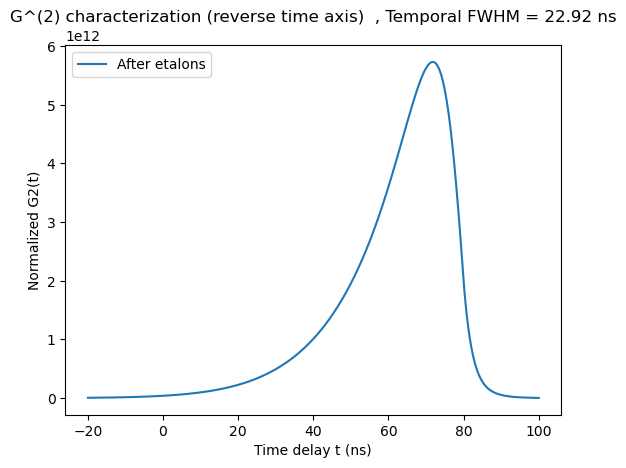

In [19]:
import matplotlib.pyplot as plt

fwhm, t_left, t_right = extract_fwhm(t_grid, G2_etalon)

plt.plot(t_grid*1e9, G2_etalon[::-1], label="After etalons")
# plt.axhline(0.5, linestyle="--", label="Half maximum")
# plt.axvline(t_left*1e9, linestyle="--")
# plt.axvline(t_right*1e9, linestyle="--")

plt.xlabel("Time delay t (ns)")
plt.ylabel("Normalized G2(t)")
plt.title("G^(2) characterization (reverse time axis) "+" , " f"Temporal FWHM = {fwhm*1e9:.2f} ns")
plt.legend()
plt.show()

In [9]:
def temporal(
    Delta_atom,
    omega_D0,
    alpha,
    use_fit=True,
    Delta_s_max=2*np.pi*800e6,
    N_Delta_s=801,
    t_min=-20e-9,
    t_max=100e-9,
    N_t=1001,
    phase_sign=+1
):
    """
    Calculate paper-style temporal FWHM after the etalons.

    Inputs are angular frequencies in rad/s:
        Delta_atom = 2*pi*(GHz value)
        omega_D0   = 2*pi*(GHz value)

    Relations from paper Eq. (2)-(3):
        Delta_c = Delta_atom + omega_D0
        Delta_p = (1 + k_p/k_c) omega_D0 - Delta_c
    """
    Delta_c = Delta_atom + omega_D0
    Delta_p = (1 + kp_over_kc) * omega_D0 - Delta_c

    Delta_s_grid, F, kappa, zeta, xi = compute_F_spectrum_fast(
        Delta_c=Delta_c, Delta_p=Delta_p,
        alpha=alpha, Gamma=Gamma, Gamma_D=Gamma_D,
        Delta_s_max=2*np.pi*800e6, N_Delta_s=801,
        wD_points=601, wD_span=6,
        chunk=50,          # smaller chunk = gentler on laptop RAM (~18 MB/chunk)
    )
    t_grid = np.linspace(t_min,t_max,N_t)
    G2 = compute_G2_from_F(Delta_s_grid, F, t_grid)

    F_etalon = apply_etalons(F, Delta_s_grid)
    G2_etalon = compute_G2_from_F(Delta_s_grid, F_etalon, t_grid)

    t_grid = np.linspace(t_min, t_max, N_t)


    fwhm, t_left, t_right = extract_fwhm(t_grid, G2_etalon)

    return fwhm

In [11]:

alpha=420
Delta_atom=2*np.pi*2.28e9
omega_D0=0

fwhm = temporal(
    Delta_atom,
    omega_D0,
    alpha,
    use_fit=True,
    Delta_s_max=2*np.pi*800e6,
    N_Delta_s=801,
    t_min=-20e-9,
    t_max=100e-9,
    N_t=1001,
    phase_sign=+1
)

[rho0] 601 steady states in 0.60 s
[spectrum] total 27.20 s (801 x 601 grid)


In [15]:
print(fwhm)

2.2923954700322476e-08
